# Notebook 6 — PSO Feature Selection (+ GA vs PSO)

## Why this notebook exists

Notebook 5 used a Genetic Algorithm. Here we use another nature-inspired
method: **Particle Swarm Optimization (PSO)**.

PSO is inspired by birds flocking or fish schooling:

| Swarm idea | Our code idea |
|---|---|
| Particle | One candidate feature subset |
| Position | Continuous numbers, one per feature |
| Velocity | How the position changes each iteration |
| Personal best (pbest) | Best position that particle has found |
| Global best (gbest) | Best position found by the whole swarm |

Because feature selection needs **0/1 masks**, we convert each continuous
position into a binary mask with a **sigmoid transfer function**.

| | |
|---|---|
| **Input** | `X_train.csv`, `y_train.csv`, and GA result from notebook 5 |
| **Output** | PSO result, winner JSON, comparison charts |
| **Why it is needed** | Fair GA vs PSO comparison; winning subset trains TabNet next. |

## Same fitness as GA (fair comparison)

\[
\text{fitness} = \text{CV F1} - \lambda \times \frac{\text{selected}}{\text{total}}
\]

Same small Random Forest, same 3-fold CV, same \(\lambda = 0.05\).
Only the **search method** changes.

In [1]:
import os
import json
import math
import random
import time

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"
os.makedirs(FIGURE_FOLDER, exist_ok=True)

X_train = pd.read_csv(CLEAN_FOLDER + "/X_train.csv")
y_train = pd.read_csv(CLEAN_FOLDER + "/y_train.csv")["Churn"].tolist()
feature_names = list(X_train.columns)
X_values = X_train.values
n_features = len(feature_names)

with open(CLEAN_FOLDER + "/ga_feature_selection.json", "r", encoding="utf-8") as f:
    ga_result = json.load(f)

print("Features:", n_features)
print("Loaded GA result:", ga_result["n_selected"], "features | CV F1 =", round(ga_result["cv_f1_selected"], 4))

Features: 33
Loaded GA result: 17 features | CV F1 = 0.6806


## Step 1 — PSO settings and helper functions

Velocity update (for each feature dimension \(j\)):

\[
v_j = w v_j + c_1 r_1 (pbest_j - x_j) + c_2 r_2 (gbest_j - x_j)
\]

- \(w\) = inertia (keep moving)
- \(c_1\) = cognitive pull toward personal best
- \(c_2\) = social pull toward global best
- \(r_1, r_2\) = random numbers between 0 and 1

In [2]:
SWARM_SIZE = 20
N_ITERS = 25
W = 0.7
C1 = 1.5
C2 = 1.5
LAMBDA_SPARSITY = 0.05
CV_SPLITS = 3
V_MAX = 4.0


def make_random_forest():
    return RandomForestClassifier(
        n_estimators=60,
        max_depth=6,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )


def count_selected(mask):
    total = 0
    for bit in mask:
        if bit == 1:
            total = total + 1
    return total


def sigmoid(x):
    """Squash a number into a probability between 0 and 1."""
    # Clip to avoid math overflow for very large |x|
    if x > 10:
        x = 10
    if x < -10:
        x = -10
    return 1.0 / (1.0 + math.exp(-x))


def position_to_mask(position):
    """
    Convert continuous position to a 0/1 feature mask.
    Higher position value -> higher chance the feature is selected.
    """
    mask = []
    probabilities = []

    for value in position:
        p = sigmoid(value)
        probabilities.append(p)
        if random.random() < p:
            mask.append(1)
        else:
            mask.append(0)

    if count_selected(mask) == 0:
        # Turn on the feature with the highest probability
        best_i = 0
        for i in range(1, n_features):
            if probabilities[i] > probabilities[best_i]:
                best_i = i
        mask[best_i] = 1

    return mask


def fitness(mask):
    selected_count = count_selected(mask)
    if selected_count == 0:
        return 0.0

    selected_positions = []
    for i in range(n_features):
        if mask[i] == 1:
            selected_positions.append(i)

    X_subset = X_values[:, selected_positions]
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(
        make_random_forest(), X_subset, y_train, cv=cv, scoring="f1"
    )
    mean_f1 = float(scores.mean())
    penalty = LAMBDA_SPARSITY * (selected_count / n_features)
    return mean_f1 - penalty


def copy_list(values):
    copied = []
    for value in values:
        copied.append(value)
    return copied


print("PSO helpers ready.")
print("Swarm size:", SWARM_SIZE, "| iterations:", N_ITERS)

PSO helpers ready.
Swarm size: 20 | iterations: 25


## Step 2 — Run the swarm

This cell takes a few minutes (same reason as GA: each fitness call trains RF).

In [3]:
start_time = time.time()

# Initialise particles
positions = []
velocities = []
masks = []
pbest_positions = []
pbest_masks = []
pbest_fitness = []

for i in range(SWARM_SIZE):
    position = []
    velocity = []
    for j in range(n_features):
        position.append(random.uniform(-1, 1))
        velocity.append(random.uniform(-0.5, 0.5))

    mask = position_to_mask(position)
    fit = fitness(mask)

    positions.append(position)
    velocities.append(velocity)
    masks.append(mask)
    pbest_positions.append(copy_list(position))
    pbest_masks.append(copy_list(mask))
    pbest_fitness.append(fit)

# Global best = best among personal bests
gbest_index = 0
for i in range(1, SWARM_SIZE):
    if pbest_fitness[i] > pbest_fitness[gbest_index]:
        gbest_index = i

gbest_position = copy_list(pbest_positions[gbest_index])
gbest_mask = copy_list(pbest_masks[gbest_index])
gbest_fit = pbest_fitness[gbest_index]

best_history = [gbest_fit]
mean_history = []
total = 0.0
for value in pbest_fitness:
    total = total + value
mean_history.append(total / SWARM_SIZE)

for iteration in range(N_ITERS):
    for i in range(SWARM_SIZE):
        for j in range(n_features):
            r1 = random.random()
            r2 = random.random()

            cognitive = C1 * r1 * (pbest_positions[i][j] - positions[i][j])
            social = C2 * r2 * (gbest_position[j] - positions[i][j])
            new_velocity = W * velocities[i][j] + cognitive + social

            # Clamp velocity
            if new_velocity > V_MAX:
                new_velocity = V_MAX
            if new_velocity < -V_MAX:
                new_velocity = -V_MAX

            velocities[i][j] = new_velocity
            positions[i][j] = positions[i][j] + new_velocity

        mask = position_to_mask(positions[i])
        fit = fitness(mask)

        if fit > pbest_fitness[i]:
            pbest_fitness[i] = fit
            pbest_positions[i] = copy_list(positions[i])
            pbest_masks[i] = copy_list(mask)

        if fit > gbest_fit:
            gbest_fit = fit
            gbest_position = copy_list(positions[i])
            gbest_mask = copy_list(mask)

    best_history.append(gbest_fit)
    total = 0.0
    for value in pbest_fitness:
        total = total + value
    mean_history.append(total / SWARM_SIZE)

    print(
        "Iter", iteration,
        "| gbest =", round(gbest_fit, 4),
        "| mean pbest =", round(mean_history[-1], 4),
        "| bits =", count_selected(gbest_mask),
    )

pso_seconds = time.time() - start_time
print()
print("PSO finished in", round(pso_seconds, 1), "seconds")
print("Best fitness:", round(gbest_fit, 4))
print("Features selected:", count_selected(gbest_mask), "/", n_features)

Iter 0 | gbest = 0.6328 | mean pbest = 0.5863 | bits = 17


Iter 1 | gbest = 0.6328 | mean pbest = 0.5975 | bits = 17


Iter 2 | gbest = 0.6328 | mean pbest = 0.5985 | bits = 17


Iter 3 | gbest = 0.6328 | mean pbest = 0.6019 | bits = 17


Iter 4 | gbest = 0.6376 | mean pbest = 0.6073 | bits = 23


...

Iter 20 | gbest = 0.6445 | mean pbest = 0.628 | bits = 19


Iter 21 | gbest = 0.6445 | mean pbest = 0.6281 | bits = 19


Iter 22 | gbest = 0.6445 | mean pbest = 0.6293 | bits = 19


Iter 23 | gbest = 0.6445 | mean pbest = 0.6311 | bits = 19


Iter 24 | gbest = 0.6445 | mean pbest = 0.6324 | bits = 19

PSO finished in 380.9 seconds
Best fitness: 0.6445
Features selected: 19 / 33


## Step 3 — Save PSO result and choose the winner

**Decision rule**

1. Higher CV F1 wins
2. If F1 is almost equal, prefer the smaller feature subset

The winning feature list is what TabNet will use in notebook 7.

In [4]:
selected_features = []
for i in range(n_features):
    if gbest_mask[i] == 1:
        selected_features.append(feature_names[i])

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_SEED)

f1_full = float(
    cross_val_score(make_random_forest(), X_values, y_train, cv=cv, scoring="f1").mean()
)

selected_positions = []
for i in range(n_features):
    if gbest_mask[i] == 1:
        selected_positions.append(i)

f1_pso = float(
    cross_val_score(
        make_random_forest(),
        X_values[:, selected_positions],
        y_train,
        cv=cv,
        scoring="f1",
    ).mean()
)

pso_result = {
    "algorithm": "PSO",
    "n_total_features": n_features,
    "n_selected": count_selected(gbest_mask),
    "reduction_pct": 100.0 * (1.0 - count_selected(gbest_mask) / n_features),
    "best_fitness": gbest_fit,
    "cv_f1_full": f1_full,
    "cv_f1_selected": f1_pso,
    "runtime_sec": pso_seconds,
    "selected_features": selected_features,
    "mask": gbest_mask,
}

with open(CLEAN_FOLDER + "/pso_feature_selection.json", "w", encoding="utf-8") as f:
    json.dump(pso_result, f, indent=2)

pd.Series(selected_features, name="feature").to_csv(
    CLEAN_FOLDER + "/pso_selected_features.csv", index=False
)

# Overlap with GA
ga_set = set(ga_result["selected_features"])
pso_set = set(selected_features)
shared = ga_set & pso_set
only_ga = ga_set - pso_set
only_pso = pso_set - ga_set
union_count = len(ga_set | pso_set)
if union_count == 0:
    jaccard = 0.0
else:
    jaccard = len(shared) / union_count

# Winner rule
ga_f1 = ga_result["cv_f1_selected"]
pso_f1 = f1_pso

if pso_f1 > ga_f1:
    winner = "PSO"
    winning = pso_result
elif abs(pso_f1 - ga_f1) < 1e-6 and pso_result["n_selected"] < ga_result["n_selected"]:
    winner = "PSO"
    winning = pso_result
else:
    winner = "GA"
    winning = ga_result

comparison = {
    "ga_cv_f1": ga_f1,
    "pso_cv_f1": pso_f1,
    "ga_n_selected": ga_result["n_selected"],
    "pso_n_selected": pso_result["n_selected"],
    "ga_runtime_sec": ga_result["runtime_sec"],
    "pso_runtime_sec": pso_seconds,
    "jaccard_overlap": jaccard,
    "winner": winner,
    "winning_features": winning["selected_features"],
    "winning_mask": winning["mask"],
}

with open(CLEAN_FOLDER + "/nia_feature_selection_winner.json", "w", encoding="utf-8") as f:
    json.dump(comparison, f, indent=2)

pd.Series(winning["selected_features"], name="feature").to_csv(
    CLEAN_FOLDER + "/winning_selected_features.csv", index=False
)

print("PSO selected:", pso_result["n_selected"], "| CV F1:", round(f1_pso, 4))
print("GA selected :", ga_result["n_selected"], "| CV F1:", round(ga_f1, 4))
print("Jaccard overlap:", round(jaccard, 3))
print("Shared features:", len(shared))
print("Winner:", winner)

PSO selected: 19 | CV F1: 0.6733
GA selected : 17 | CV F1: 0.6806
Jaccard overlap: 0.565
Shared features: 13
Winner: GA


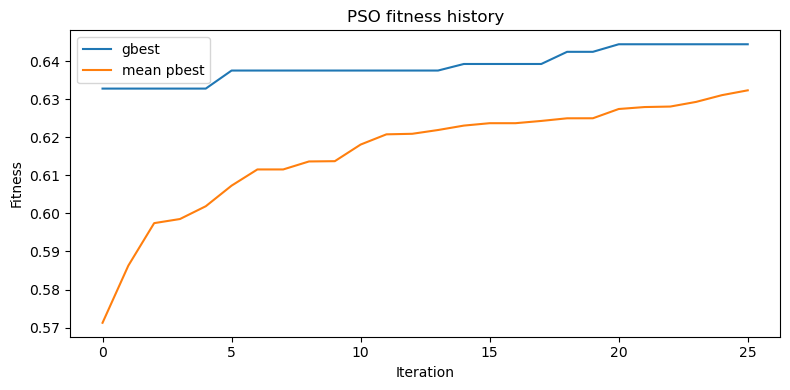

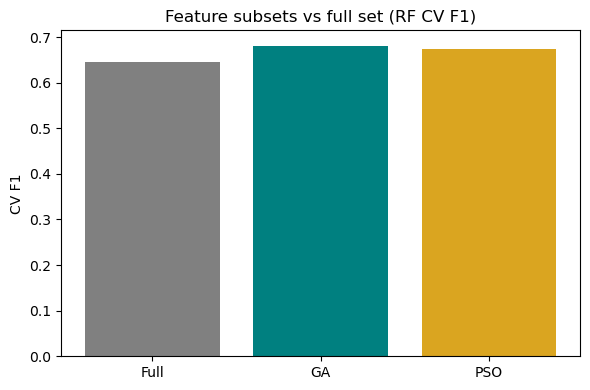

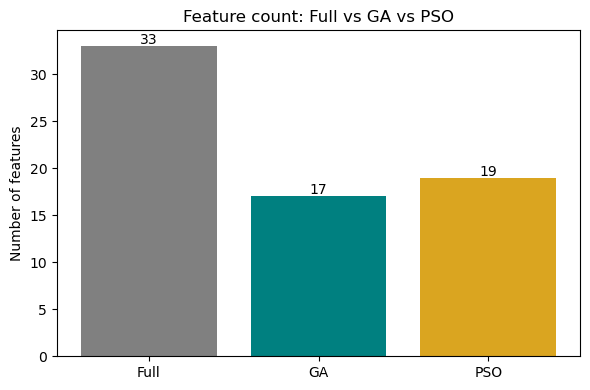

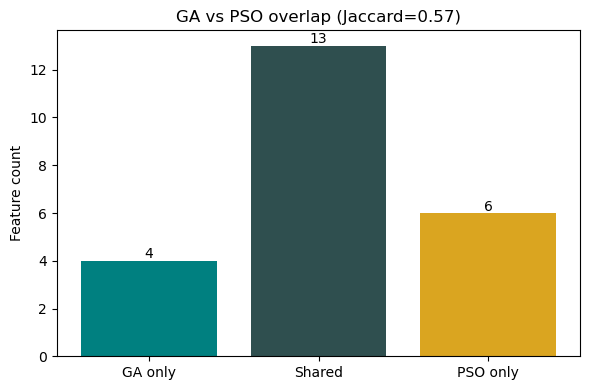

Winning features:
 - Tenure
 - WarehouseToHome
 - HourSpendOnApp
 - NumberOfAddress
 - CouponUsed
 - DaySinceLastOrder
 - CityTier
 - SatisfactionScore
 - Complain
 - IsDormant
 - UnhappyComplain
 - PreferredLoginDevice_Computer
 - PreferredPaymentMode_Cash on Delivery
 - PreferredPaymentMode_Debit Card
 - PreferedOrderCat_Laptop & Accessory
 - PreferedOrderCat_Mobile Phone
 - MaritalStatus_Single


In [5]:
# PSO fitness history
plt.figure(figsize=(8, 4))
plt.plot(best_history, label="gbest")
plt.plot(mean_history, label="mean pbest")
plt.xlabel("Iteration")
plt.ylabel("Fitness")
plt.title("PSO fitness history")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/6_pso_fitness_history.png", dpi=150)
plt.show()

# F1 comparison
plt.figure(figsize=(6, 4))
plt.bar(
    ["Full", "GA", "PSO"],
    [f1_full, ga_f1, f1_pso],
    color=["gray", "teal", "goldenrod"],
)
plt.ylabel("CV F1")
plt.title("Feature subsets vs full set (RF CV F1)")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/6_ga_vs_pso_f1.png", dpi=150)
plt.show()

# Feature counts
plt.figure(figsize=(6, 4))
counts = [n_features, ga_result["n_selected"], pso_result["n_selected"]]
plt.bar(["Full", "GA", "PSO"], counts, color=["gray", "teal", "goldenrod"])
plt.ylabel("Number of features")
plt.title("Feature count: Full vs GA vs PSO")
for i in range(len(counts)):
    plt.text(i, counts[i] + 0.2, str(counts[i]), ha="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/6_feature_counts.png", dpi=150)
plt.show()

# Overlap bars
plt.figure(figsize=(6, 4))
overlap_vals = [len(only_ga), len(shared), len(only_pso)]
plt.bar(["GA only", "Shared", "PSO only"], overlap_vals, color=["teal", "darkslategray", "goldenrod"])
plt.ylabel("Feature count")
plt.title("GA vs PSO overlap (Jaccard=" + str(round(jaccard, 2)) + ")")
for i in range(len(overlap_vals)):
    plt.text(i, overlap_vals[i] + 0.1, str(overlap_vals[i]), ha="center")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/6_ga_pso_overlap.png", dpi=150)
plt.show()

print("Winning features:")
for name in winning["selected_features"]:
    print(" -", name)

| | Genetic Algorithm | Particle Swarm Optimization |
|---|---|---|
| Inspired by | Evolution / natural selection | Bird flocks / fish schools |
| Candidate | Binary chromosome | Continuous position → binary mask |
| Improves by | Selection, crossover, mutation | Velocity toward pbest and gbest |
| Strength | Good at recombining feature blocks | Fast social sharing of good solutions |

**Shared features** are stable signals both methods like.
**Winner** is whoever has higher CV F1 (tie → fewer features).

## Conclusion of notebook 6

**Files created**

- `data/clean/pso_feature_selection.json`
- `data/clean/pso_selected_features.csv`
- `data/clean/nia_feature_selection_winner.json`
- `data/clean/winning_selected_features.csv`
- charts `figures/6_*.png`

**Next:** notebook 7 trains TabNet on the winning feature subset.